<a href="https://colab.research.google.com/github/M-zavvar/afmz/blob/main/Breast_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

url = 'https://raw.githubusercontent.com/M-zavvar/afmz/25634f4a1544a722fb63f476ed7d45838fb85882/data.csv'
df = pd.read_csv(url)

In [6]:
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("Class Distribution:")
print(df['diagnosis'].value_counts())

# Check for missing values
print(df.isnull().sum())

Number of samples: 569
Number of features: 33
Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_wo

In [7]:
# 1. Clean the data (Drop ID and the empty column)
df = df.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

# 2. Encode the target variable (M = 1, B = 0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# 3. Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 4. SPLIT FIRST to avoid Data Leakage (Section 6 Requirement)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Normalize/Scale the data fitting ONLY on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transform test data based on train data

In [8]:
# Initialize models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the models
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

--- Logistic Regression ---
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


--- Random Forest ---
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



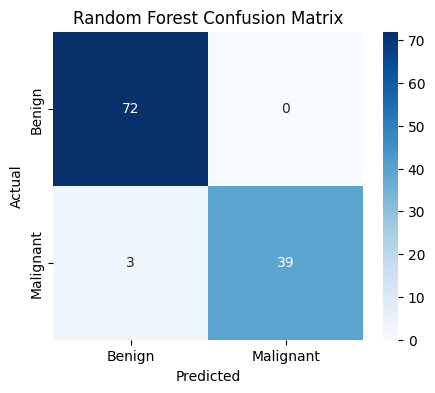

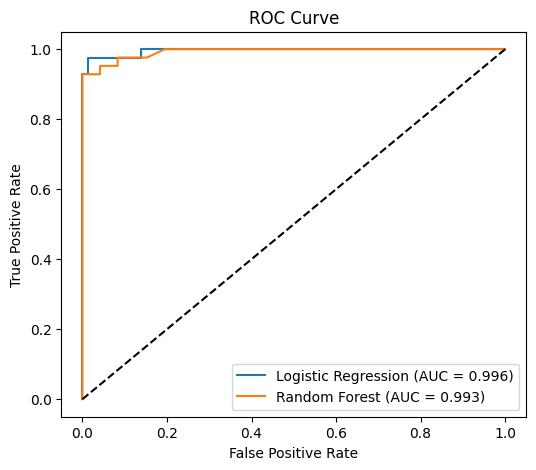

In [9]:
# 1. Performance Scores
print("--- Logistic Regression ---")
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Malignant']))

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))

# 2. Confusion Matrix (Plotting for Random Forest)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show() # Save this image by right-clicking it and paste it into your Word doc!

# 3. ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_scaled)[:,1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg.predict_proba(X_test_scaled)[:,1])
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show() # Save this image too!